# חיזוי מהירות הליכה לרובוט מלווה

מודל ‎XGBoost‎ שמנבא את מהירות ההליכה של אדם **3 צעדים קדימה** (≈0.36 שניות בקצב 8.3Hz),
כדי שרובוט מלווה יקדים ויתאים את תנועתו במקום להגיב באיחור.

האימון והבדיקה מבוצעים על נתוני חיישן אמיתיים מהרובוט, עם חלוקה לפי אדם
כך שהבדיקה נעשית על נסיינים שהמודל מעולם לא ראה.

In [1]:
from google.colab import drive
import glob
import os
import pandas as pd

# Mount Google Drive (approve access in the pop-up window).
drive.mount('/content/drive')

Mounted at /content/drive


## הערה על מקור הנתונים

בגרסאות קודמות אומן המודל על מאגר ‎HuGaDB‎, שבו אין מהירות אמיתית — היא חושבה
מהאצה דרך נוסחה, כלומר מהירות מפוברקת. כאן אנו מאמנים ובודקים אך ורק על קבצי
החיישן האמיתיים של הרובוט, שכבר מכילים מהירות נמדדת (`speed_mps`).

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.metrics import mean_squared_error

color_pal = sns.color_palette()
plt.style.use('fivethirtyeight')

# טעינת הנתונים, ניקוי ובניית מאפיינים

לכל קובץ: סינון קוצי רעש פיזיקליים, החלקה, ובניית 55 מאפיינים (50 לגים + 5 מאפייני מגמה).
החלוקה לאימון/בדיקה נעשית לפי אדם (`GroupShuffleSplit`) כדי למנוע דליפת מידע בין נסיין שמופיע בשני הצדדים.

In [3]:
import glob, os, gc
import pandas as pd, numpy as np
from sklearn.model_selection import GroupShuffleSplit

HORIZON   = 3      # how many steps ahead to predict (~0.36 s at 8.3 Hz)
MAX_SPEED = 5.0    # physical ceiling: anything above this is sensor noise, not real speed
SMOOTH    = 5      # smoothing window applied after filtering. Set to 1 to disable.

# Person id = name of the file's parent folder:  Experiments/<person>/<file>.csv
def person_of(path):
    return os.path.basename(os.path.dirname(path))

def build_one(fn, horizon):
    df = pd.read_csv(fn)
    if 'speed_mps' not in df.columns:           # robust to 2- or 4-column formats
        return None
    s = pd.to_numeric(df['speed_mps'], errors='coerce').dropna().reset_index(drop=True)
    if len(s) < 60:                             # skip files that are too short
        return None

    # Step 1: remove physically impossible spikes (sensor noise).
    # Replace out-of-range values with NaN, then fill from neighbours so the lag chain stays intact.
    s = s.mask(s > MAX_SPEED).mask(s < 0)
    s = s.ffill().bfill()

    # Step 2: smooth the cleaned signal.
    if SMOOTH > 1:
        s = s.rolling(SMOOTH, min_periods=1).mean()

    # Build features: 50 lags + rolling stats + trend terms.
    f = pd.DataFrame()
    for i in range(0, 50):
        f[f'lag_{i}'] = s.shift(i)
    f['roll_mean_5']  = s.rolling(5).mean()
    f['roll_std_5']   = s.rolling(5).std()
    f['roll_mean_10'] = s.rolling(10).mean()
    f['trend_5']  = s - s.shift(5)
    f['trend_10'] = s - s.shift(10)
    f['y']      = s.shift(-horizon)             # target: speed `horizon` steps in the future
    f['person'] = person_of(fn)
    return f.dropna()

# Load every recording from the experiments folder.
folder_path = '/content/drive/MyDrive/Colab Notebooks/Experiments'
all_files = glob.glob(os.path.join(folder_path, '*', '*.csv'))
print(f"Found {len(all_files)} files")

frames = [b for b in (build_one(fn, HORIZON) for fn in all_files) if b is not None]
data = pd.concat(frames, ignore_index=True)

groups = data['person'].values
feature_cols = [c for c in data.columns if c not in ('y', 'person')]
X = data[feature_cols].values.astype(np.float32)
y = data['y'].values.astype(np.float32)

# Split by person: a whole person is either in train or in test, never both.
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
tr_idx, te_idx = next(gss.split(X, y, groups))

X_train, X_test = X[tr_idx], X[te_idx]
y_train, y_test = y[tr_idx], y[te_idx]
naive_test = X_test[:, 0]                        # lag_0 = the current speed (persistence baseline)
chg = np.abs(data['trend_5'].values)[te_idx]     # magnitude of change, used to flag transition states

n_tr_people = len(set(groups[tr_idx]))
n_te_people = len(set(groups[te_idx]))
assert set(groups[tr_idx]).isdisjoint(set(groups[te_idx])), "Leakage: same person on both sides"
print(f"Horizon: {HORIZON} steps | train: {X_train.shape} from {n_tr_people} people"
      f" | test: {X_test.shape} from {n_te_people} unseen people")
gc.collect()

Found 209 files
Horizon: 3 steps | train: (30500, 55) from 61 people | test: (7648, 55) from 16 unseen people


0

# ביצועים לפי מצב תנועה

נשווה את המודל לניחוש הנאיבי (persistence — "המהירות הבאה זהה לנוכחית") בשלושה חתכים:
כלל הבדיקה, מצבי מעבר (25% הדגימות הדינמיות ביותר), ומצב יציב. הסיפור המרכזי נמצא ב**מצבי המעבר**.

In [4]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

model = xgb.XGBRegressor(n_estimators=300, max_depth=5, learning_rate=0.05,
                         random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
pred = model.predict(X_test)

def stats(name, p, mask=None):
    a, q = (y_test, p) if mask is None else (y_test[mask], p[mask])
    print(f"{name:12s} | RMSE {np.sqrt(mean_squared_error(a,q)):.3f}"
          f" | MAE {mean_absolute_error(a,q):.3f} | R2 {r2_score(a,q)*100:.1f}%")

trans = chg > np.percentile(chg, 75)   # top 25% most dynamic samples = transition states
print("===== All test =====");         stats("XGBoost", pred);        stats("Naive", naive_test)
print("\n===== Transition states ====="); stats("XGBoost", pred, trans); stats("Naive", naive_test, trans)
print("\n===== Steady state =====");    stats("XGBoost", pred,~trans); stats("Naive", naive_test,~trans)

===== All test =====
XGBoost      | RMSE 0.165 | MAE 0.117 | R2 91.9%
Naive        | RMSE 0.194 | MAE 0.141 | R2 88.7%

===== Transition states =====
XGBoost      | RMSE 0.215 | MAE 0.157 | R2 89.4%
Naive        | RMSE 0.246 | MAE 0.182 | R2 86.2%

===== Steady state =====
XGBoost      | RMSE 0.144 | MAE 0.104 | R2 93.0%
Naive        | RMSE 0.174 | MAE 0.127 | R2 89.8%


## גרף: שגיאה מול אופק החיזוי

הגרף משווה את שגיאת המודל (אדום) לשגיאת הניחוש הנאיבי (ירוק) ככל שמנסים לחזות רחוק יותר קדימה.
ככל שהאופק גדל, שתי השגיאות עולות — אבל המודל שומר על פער עקבי לטובתו, והפער הגדול ביותר נמצא
באופקים הקצרים, בדיוק הטווח שבו הרובוט צריך להקדים. בחרנו אופק של 3 צעדים כאיזון בין הקדמה מספקת לדיוק גבוה.

Horizon 1: model=0.059 | naive=0.074 | improvement=20.0%
Horizon 2: model=0.111 | naive=0.138 | improvement=19.6%
Horizon 3: model=0.165 | naive=0.194 | improvement=15.2%
Horizon 5: model=0.266 | naive=0.282 | improvement=5.6%
Horizon 8: model=0.332 | naive=0.347 | improvement=4.2%
Horizon 10: model=0.352 | naive=0.371 | improvement=5.3%


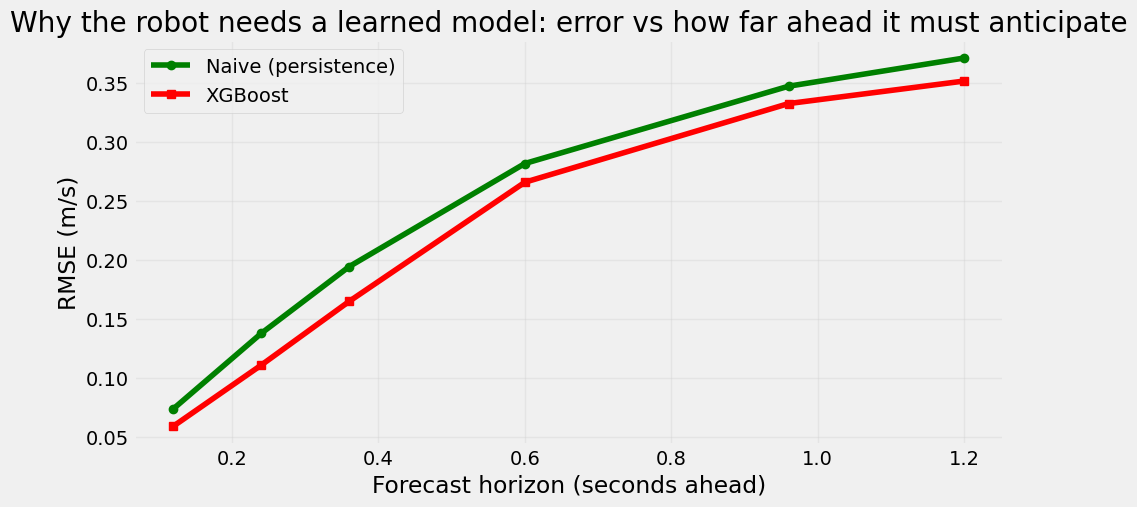

In [5]:
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupShuffleSplit

def eval_horizon(h):
    # Build the dataset for horizon h, split by person, train, and return RMSE of model vs naive.
    frames = [b for b in (build_one(fn, h) for fn in all_files) if b is not None]
    d = pd.concat(frames, ignore_index=True)
    g  = d['person'].values
    fc = [c for c in d.columns if c not in ('y', 'person')]
    Xx = d[fc].values.astype(np.float32)
    yy = d['y'].values.astype(np.float32)
    tr, te = next(GroupShuffleSplit(n_splits=1, test_size=0.2,
                                    random_state=42).split(Xx, yy, g))
    mdl = xgb.XGBRegressor(n_estimators=300, max_depth=5, learning_rate=0.05,
                           random_state=42, n_jobs=-1).fit(Xx[tr], yy[tr])
    rm = np.sqrt(mean_squared_error(yy[te], mdl.predict(Xx[te])))
    rn = np.sqrt(mean_squared_error(yy[te], Xx[te, 0]))   # naive = lag_0
    return rm, rn

horizons = [1, 2, 3, 5, 8, 10]
m_rmse, n_rmse = [], []
for h in horizons:
    rm, rn = eval_horizon(h)
    m_rmse.append(rm); n_rmse.append(rn)
    print(f"Horizon {h}: model={rm:.3f} | naive={rn:.3f} | improvement={100*(1-rm/rn):.1f}%")

plt.figure(figsize=(10,5))
sec = [h*0.12 for h in horizons]
plt.plot(sec, n_rmse, 'o-', label='Naive (persistence)', color='green')
plt.plot(sec, m_rmse, 's-', label='XGBoost', color='red')
plt.xlabel('Forecast horizon (seconds ahead)'); plt.ylabel('RMSE (m/s)')
plt.title('Why the robot needs a learned model: error vs how far ahead it must anticipate')
plt.legend(); plt.grid(alpha=.3); plt.show()

# חלוקת אימון / בדיקה

## גרף: רצף האימון מול הבדיקה
הגרף מציג את מהירות היעד לאורך דגימות האימון (כחול) ואחריהן דגימות הבדיקה (כתום).
הוא ממחיש שהבדיקה מורכבת מנסיינים נפרדים, ושטווח המהירויות בשני החלקים דומה.

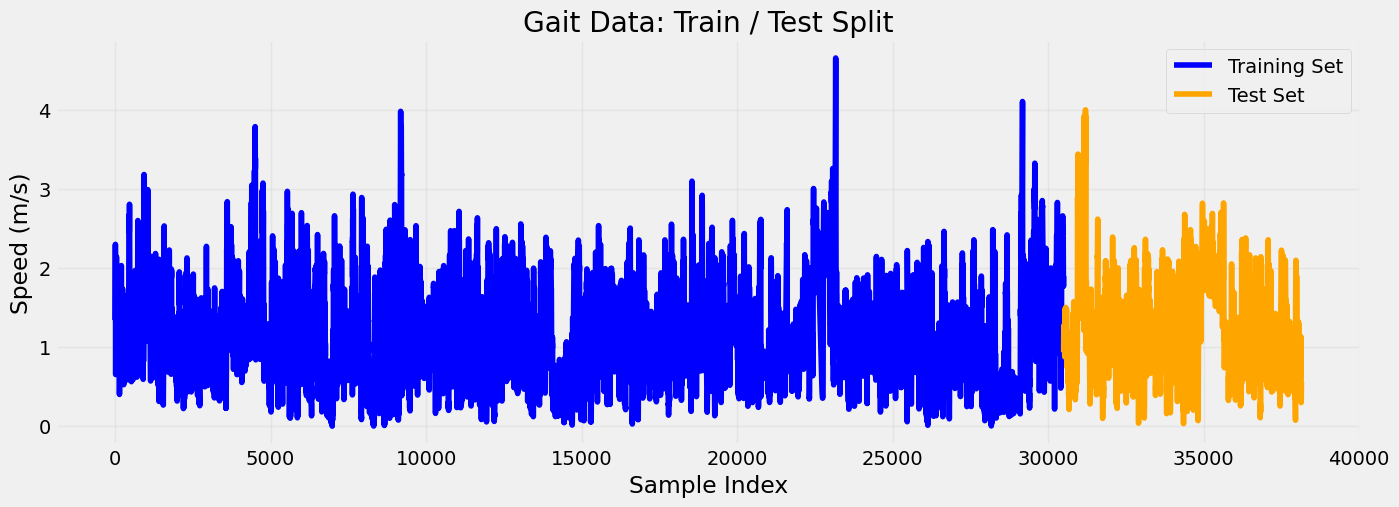

In [6]:
import matplotlib.pyplot as plt

# Visualize the train / test split along the sample order.
plt.figure(figsize=(15, 5))
plt.plot(range(len(y_train)), y_train, label='Training Set', color='blue')
plt.plot(range(len(y_train), len(y_train) + len(y_test)), y_test, label='Test Set', color='orange')
plt.title('Gait Data: Train / Test Split')
plt.xlabel('Sample Index')
plt.ylabel('Speed (m/s)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## גרף: חלון מקרוב של אות המהירות
מבט מקרוב על קטע רציף מתוך נתוני האימון, כדי לראות את מבנה אות ההליכה לאחר הניקוי וההחלקה —
התנודתיות הטבעית של מהירות ההליכה ברמת הדגימה הבודדת.

Total length of y_train: 30500
Plotting from index 1000 to 1500


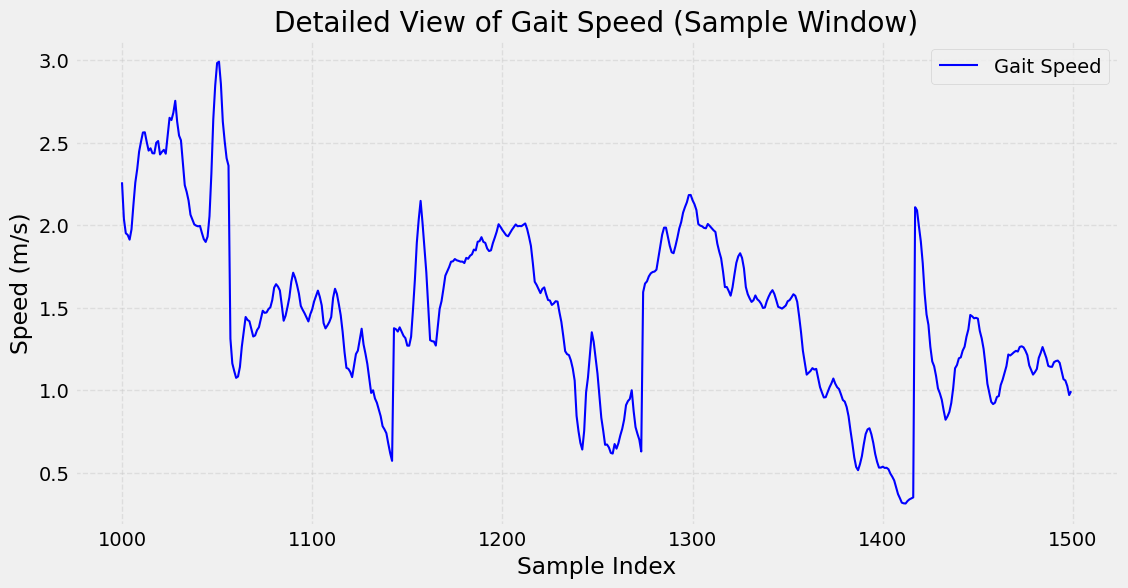

In [7]:
import matplotlib.pyplot as plt
import numpy as np

print(f"Total length of y_train: {len(y_train)}")

# Pick a safe window; fall back to the start/end if the data is shorter than expected.
actual_start = 1000 if len(y_train) > 1000 else 0
actual_end   = 1500 if len(y_train) > 1500 else len(y_train)
print(f"Plotting from index {actual_start} to {actual_end}")

y_slice = y_train[actual_start:actual_end]
if isinstance(y_slice, np.ndarray):
    y_slice = np.nan_to_num(y_slice)

plt.figure(figsize=(12, 6))
if len(y_slice) > 0:
    x_axis = range(actual_start, actual_start + len(y_slice))
    plt.plot(x_axis, y_slice, color='blue', linewidth=1.5, label='Gait Speed')
    plt.title('Detailed View of Gait Speed (Sample Window)')
    plt.xlabel('Sample Index')
    plt.ylabel('Speed (m/s)')
    plt.grid(True, which='both', linestyle='--', alpha=0.5)
    plt.legend()
plt.show()

# בניית המודל ואימונו

מאמנים ‎XGBoost‎ עם עצירה מוקדמת (early stopping) על סט האימון, ומנטרים את השגיאה על סט הבדיקה.

In [8]:
# The features are already packed into X during file loading (build_one in the cell above).
TARGET = 'speed_mps'
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

X_train shape: (30500, 55)
y_train shape: (30500,)


In [9]:
reg = xgb.XGBRegressor(base_score=0.5,
                       booster='gbtree',
                       n_estimators=1000,
                       early_stopping_rounds=50,
                       objective='reg:squarederror',
                       max_depth=3,
                       learning_rate=0.01)

reg.fit(X_train, y_train,
        eval_set=[(X_train, y_train), (X_test, y_test)],
        verbose=100)

[0]	validation_0-rmse:0.88815	validation_1-rmse:0.97593
[100]	validation_0-rmse:0.38327	validation_1-rmse:0.41178
[200]	validation_0-rmse:0.23962	validation_1-rmse:0.24040
[300]	validation_0-rmse:0.20695	validation_1-rmse:0.19827
[400]	validation_0-rmse:0.19873	validation_1-rmse:0.18867
[500]	validation_0-rmse:0.19510	validation_1-rmse:0.18536
[600]	validation_0-rmse:0.19250	validation_1-rmse:0.18334
[700]	validation_0-rmse:0.19002	validation_1-rmse:0.18178
[800]	validation_0-rmse:0.18771	validation_1-rmse:0.18015
[900]	validation_0-rmse:0.18554	validation_1-rmse:0.17851
[999]	validation_0-rmse:0.18360	validation_1-rmse:0.17699


XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=50,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)

# חשיבות המאפיינים

## גרף: על מה המודל מסתמך
הגרף מציג את 15 המאפיינים המשפיעים ביותר. המהירות הנוכחית (lag_0) היא החזקה ביותר — הגיוני —
אך המודל נשען גם על מאפייני מגמה וממוצעים נעים, וזה מה שמאפשר לו לזהות האצה או האטה ולהקדים אותה.

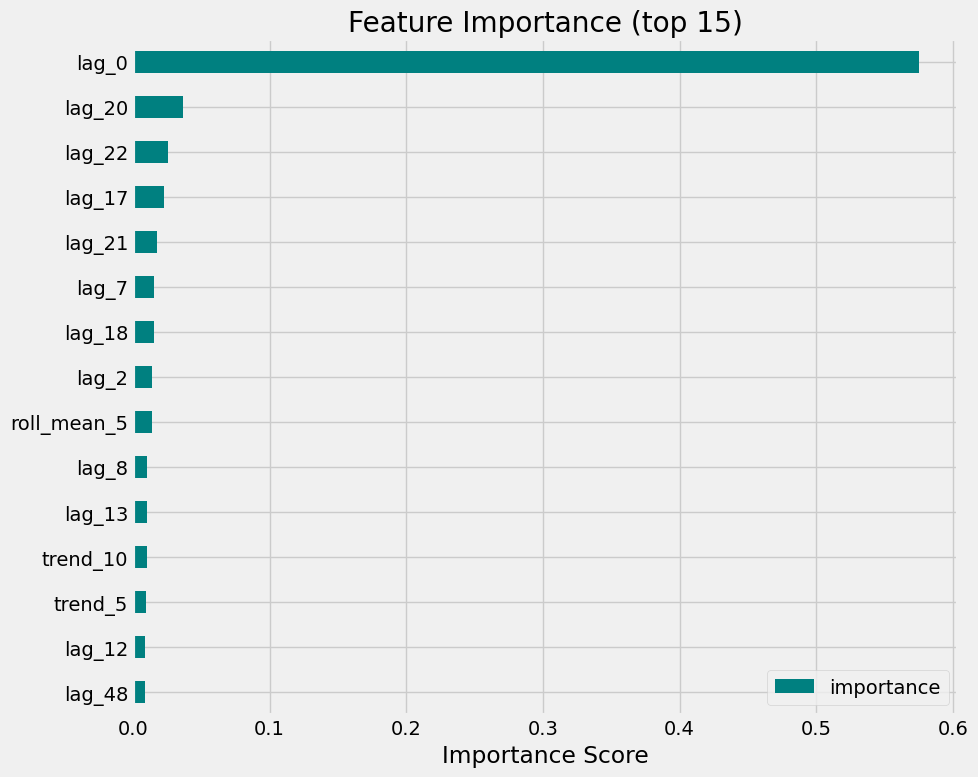

In [10]:
# Feature names in the exact order built by build_one: 50 lags + 5 trend/rolling features.
feature_names = (
    [f'lag_{i}' for i in range(0, 50)]          # lag_0 .. lag_49
    + ['roll_mean_5', 'roll_std_5', 'roll_mean_10', 'trend_5', 'trend_10']
)

assert len(feature_names) == reg.feature_importances_.shape[0], \
    f"{len(feature_names)} names vs {reg.feature_importances_.shape[0]} features"

fi = pd.DataFrame(data=reg.feature_importances_,
                  index=feature_names,
                  columns=['importance'])

# Show only the top 15 (55 bars would be too dense to read).
fi.sort_values('importance').tail(15).plot(
    kind='barh', title='Feature Importance (top 15)', figsize=(10, 8), color='teal')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

# תחזית מול מציאות

## גרף: התחזית לעומת המהירות האמיתית
הגרף משווה את תחזית המודל (כתום מקווקו) למהירות שנמדדה בפועל (כחול) על 500 הדגימות הראשונות
של נסיינים שהמודל לא ראה. ניתן לראות שהתחזית עוקבת צמוד אחר התנודות, כולל ההאצה החדה לקראת סוף הקטע.

Total points in the test set: 7648


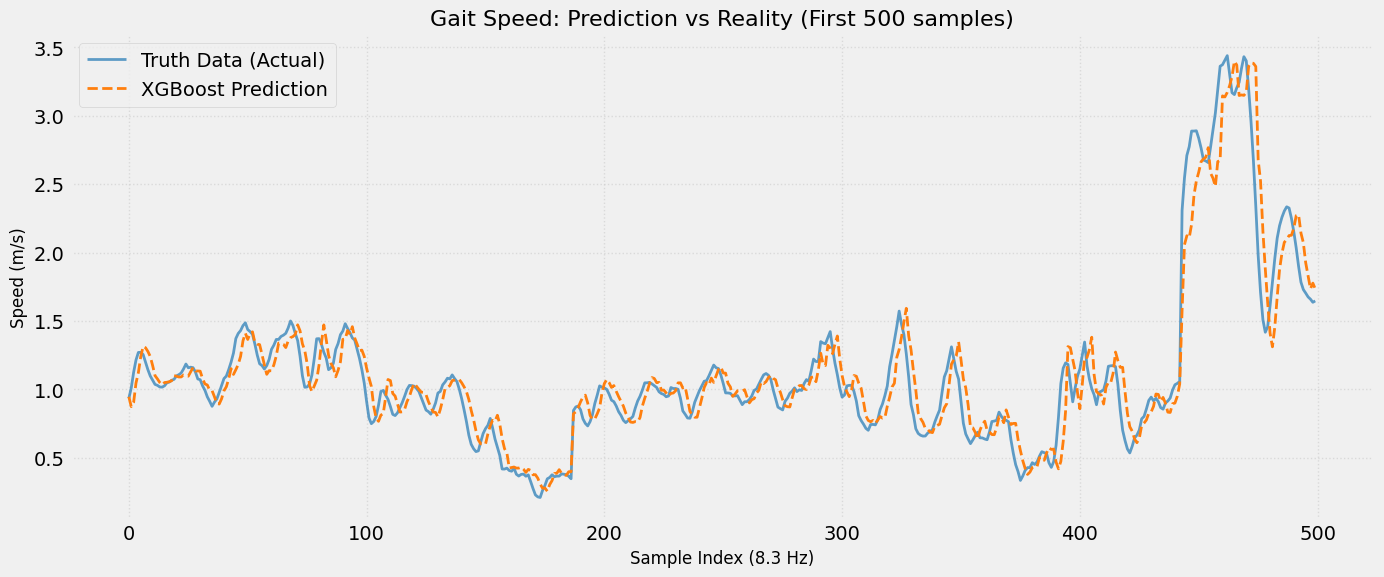

In [11]:
predictions = reg.predict(X_test)

actual_size = len(y_test)
print(f"Total points in the test set: {actual_size}")

# Show 500 points, or everything if there are fewer.
end_plot = min(500, actual_size)

plt.figure(figsize=(15, 6))
plt.plot(range(end_plot), y_test[:end_plot],
         label='Truth Data (Actual)', color='#1f77b4', linewidth=2, alpha=0.7)
plt.plot(range(end_plot), predictions[:end_plot],
         label='XGBoost Prediction', color='#ff7f0e', linestyle='--', linewidth=2)
plt.title(f'Gait Speed: Prediction vs Reality (First {end_plot} samples)', fontsize=16)
plt.xlabel('Sample Index (8.3 Hz)', fontsize=12)
plt.ylabel('Speed (m/s)', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# הערכת ביצועים

In [12]:
from sklearn.metrics import mean_squared_error
import numpy as np

score = np.sqrt(mean_squared_error(y_test, predictions))
print(f'RMSE Score on Test set: {score:0.4f}')

RMSE Score on Test set: 0.1770


## ניתוח שגיאה
בחינת הדגימות עם השגיאה הגדולה ביותר. ברוב המקרים מדובר ברגעי מעבר חדים (האצה או האטה מהירה),
שבהם המהירות משתנה במהירות — בדיוק המצבים הקשים ביותר לחיזוי.

In [13]:
import pandas as pd
import numpy as np

TARGET = 'speed_mps'

# Build a results table from the in-memory arrays.
test = pd.DataFrame(X_test).copy()
test[TARGET]       = y_test.values if hasattr(y_test, 'values') else y_test
test['prediction'] = predictions
test['error']      = np.abs(test[TARGET] - test['prediction'])

# Show the 10 samples with the highest absolute error.
print("Top 10 samples with the highest error:")
print(test.sort_values('error', ascending=False)[['error', TARGET, 'prediction']].head(10))

print(f"\nOverall Mean Absolute Error: {test['error'].mean():.4f} m/s")

Top 10 samples with the highest error:
        error  speed_mps  prediction
654  1.545563   3.180856    1.635292
653  1.399127   2.619303    1.220176
655  1.395154   3.602005    2.206850
656  1.276167   3.850261    2.574094
680  1.096230   3.460260    2.364030
474  1.020429   2.339707    3.360135
679  0.997767   3.188197    2.190430
675  0.922071   2.356781    3.278853
652  0.917466   2.035499    1.118033
681  0.916311   3.633966    2.717655

Overall Mean Absolute Error: 0.1280 m/s


In [14]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

actual = y_test
preds  = predictions

mae  = mean_absolute_error(actual, preds)
rmse = np.sqrt(mean_squared_error(actual, preds))
r2   = r2_score(actual, preds) * 100

# Skill score: % improvement of the model over the naive baseline (lag_0 = current speed).
naive_pred = naive_test
rmse_naive = np.sqrt(mean_squared_error(actual, naive_pred))
skill = (1 - rmse / rmse_naive) * 100   # positive = model beats naive

print("=== Model performance summary ===")
print(f"R2 (fit to reality):              {r2:.2f}%")
print(f"Skill score (vs naive baseline):  {skill:.2f}%")
print("------------------------------------------")
print(f"Mean Absolute Error (MAE):        {mae:.3f} m/s")
print(f"Root Mean Squared Error (RMSE):   {rmse:.3f} m/s")

=== Model performance summary ===
R2 (fit to reality):              90.65%
Skill score (vs naive baseline):  8.83%
------------------------------------------
Mean Absolute Error (MAE):        0.128 m/s
Root Mean Squared Error (RMSE):   0.177 m/s


In [15]:
import numpy as np
from sklearn.metrics import mean_squared_error

# Naive baseline: predict that the future speed equals the current speed.
# lag_0 is the first feature column (the most recent measurement).
naive_predictions = X_test[:, 0]
naive_rmse = np.sqrt(mean_squared_error(y_test, naive_predictions))

print(f"Smart model error (XGBoost): {rmse:.3f}")
print(f"Naive baseline error (copy current speed): {naive_rmse:.3f}")

if rmse < naive_rmse:
    print("The model learned real patterns and beats the naive baseline.")
else:
    print("The model only copies the previous step - check for data leakage.")

Smart model error (XGBoost): 0.177
Naive baseline error (copy current speed): 0.194
The model learned real patterns and beats the naive baseline.


# שמירת המודל

In [16]:
reg.save_model('go2_speed_model.json')